# W05A 실습 A · 모델과 성과지표의 의미를 다시 연결하기

**딥러닝응용I(추천시스템) · 동덕여자대학교 · 유원상 교수 · 2026-2**

2026년 9월 29일 · 5주차 1차시 · 주교재 1–3장.
CPU 런타임에서 첫 셀부터 실행하세요. 파일 → Drive에 사본 저장 후 자신의 기록을 남깁니다.
설치 후 재시작 안내가 나오면 런타임을 재시작하고 첫 셀부터 다시 실행합니다.
빈칸 `None`과 빈 문자열은 연습용입니다. 뒤의 독립 시연에는 다른 변수를 사용하므로 미완성 문제를 건너뛰어도 진행할 수 있습니다.
GitHub 정의 링크와 설치 버전은 모두 `2026-fall-w05a-v2`입니다. 클래스와 함수를 열어 입력, 반환, 학습 상태를 직접 읽어 봅시다.


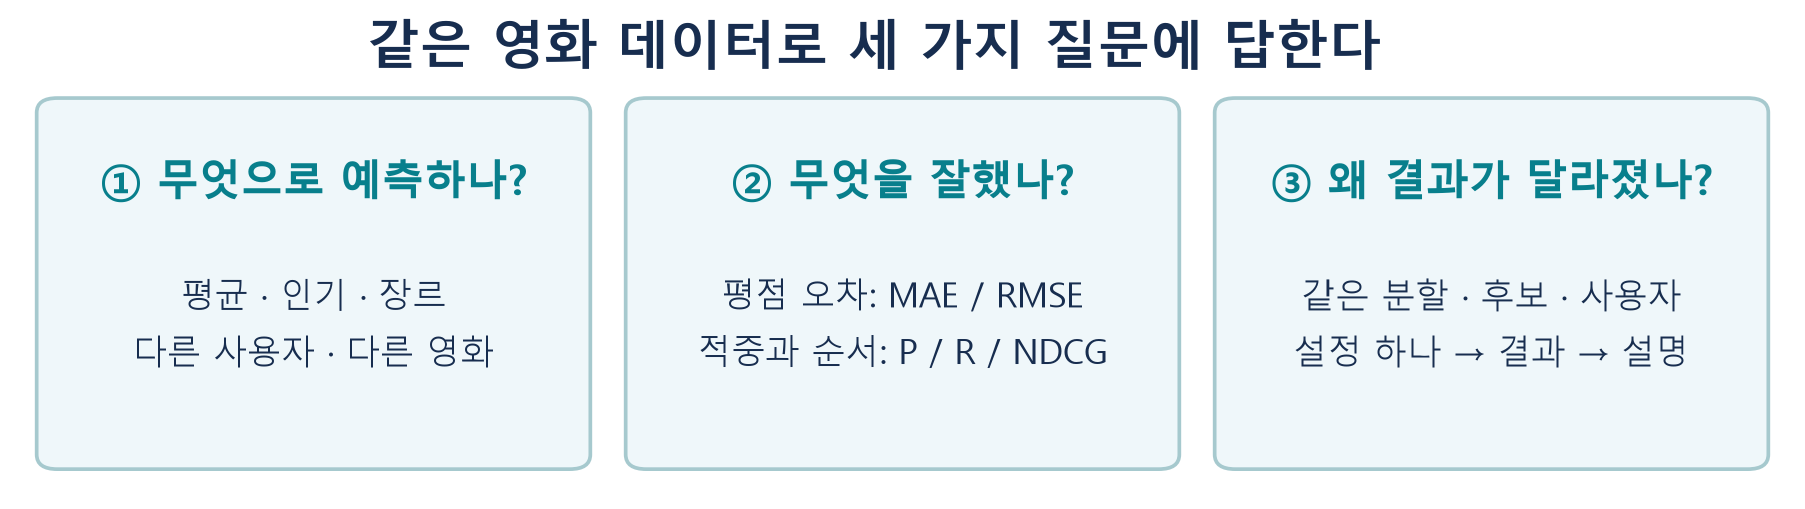


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/learning-map.png)


## 1. 공통 코드를 불러오기 전에

`ModelSpec`은 설정을 보관하는 불변 객체입니다. `ComparisonSuite`는 user_id/movie_id/rating의 학습 표, 사용자 속성 표, 영화 장르 표를 받아 기존 모델을 연결합니다. `fit`은 평균·프로필·유사도 등의 학습 상태를 구성합니다.
`comparison_toy()`는 5명·5편·18개 평점과 가상 집단/장르를 반환합니다. 실제 MovieLens의 부분집합이 아니며 다운로드가 없습니다.
`recommend(spec, user_id, top_n)`은 영화 ID/제목/장르/점수/근거/학습 평가 수 표를 반환합니다. 점수는 모델마다 단위가 다릅니다.


In [ ]:
import os, sys, subprocess, inspect
os.environ['GRADIO_ANALYTICS_ENABLED']='False'
IN_COLAB='google.colab' in sys.modules
COURSE_VERSION='2026-fall-w05a-v2'
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q',
        f'luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}',
        'gradio==6.26.0'],check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from pathlib import Path
from dataclasses import replace
from IPython.display import display, Markdown, HTML
from luna_recsys.model_comparison import (ModelSpec,ComparisonSuite,baseline_specs,tuning_specs,
    comparison_toy,split_three,cohort,compare,select_best,pair_digest,definition_link)
from luna_recsys.ranking import FourMethodRecommender,ranking_metrics
from luna_recsys.rating_models import MeanRatingPredictor
from luna_recsys.cf_synthesis import EvidenceCF
from luna_recsys.collaborative import UserCF,binary_jaccard
print('Python',sys.version.split()[0], 'Gradio',gr.__version__, '설치 버전',COURSE_VERSION)


In [ ]:
api_objects=[ModelSpec,ComparisonSuite,ComparisonSuite.model,ComparisonSuite.recommend,
    ComparisonSuite.evaluate,baseline_specs,tuning_specs,comparison_toy,split_three,cohort,
    compare,select_best,pair_digest,ranking_metrics,MeanRatingPredictor,MeanRatingPredictor.fit,
    MeanRatingPredictor.predict_details,FourMethodRecommender,FourMethodRecommender.fit,
    FourMethodRecommender.score_catalog,EvidenceCF,EvidenceCF.fit,EvidenceCF.configured,
    EvidenceCF.predict_details,EvidenceCF.explain,UserCF,UserCF.fit,binary_jaccard,definition_link]
display(Markdown('\n'.join(f'- [{obj.__qualname__}]({definition_link(obj,COURSE_VERSION)})' for obj in api_objects)))


정의 링크를 누르거나 `help(ComparisonSuite.evaluate)`로 계약을 확인할 수 있습니다. 아래는 다섯 영화의 같은 좌표계를 유지한 표입니다.


In [ ]:
toy=comparison_toy()
R=toy.ratings.pivot(index='user_id',columns='movie_id',values='rating')
display(R)
small_suite=ComparisonSuite(toy.ratings,toy.users,toy.movies)
small_outputs=[]
for spec in baseline_specs():
    top=small_suite.recommend(spec,1,2)
    small_outputs.append(dict(model=spec.name,movies=top.title.tolist(),scores=top.score.round(4).tolist(),basis=top.basis.tolist()))
display(pd.DataFrame(small_outputs))


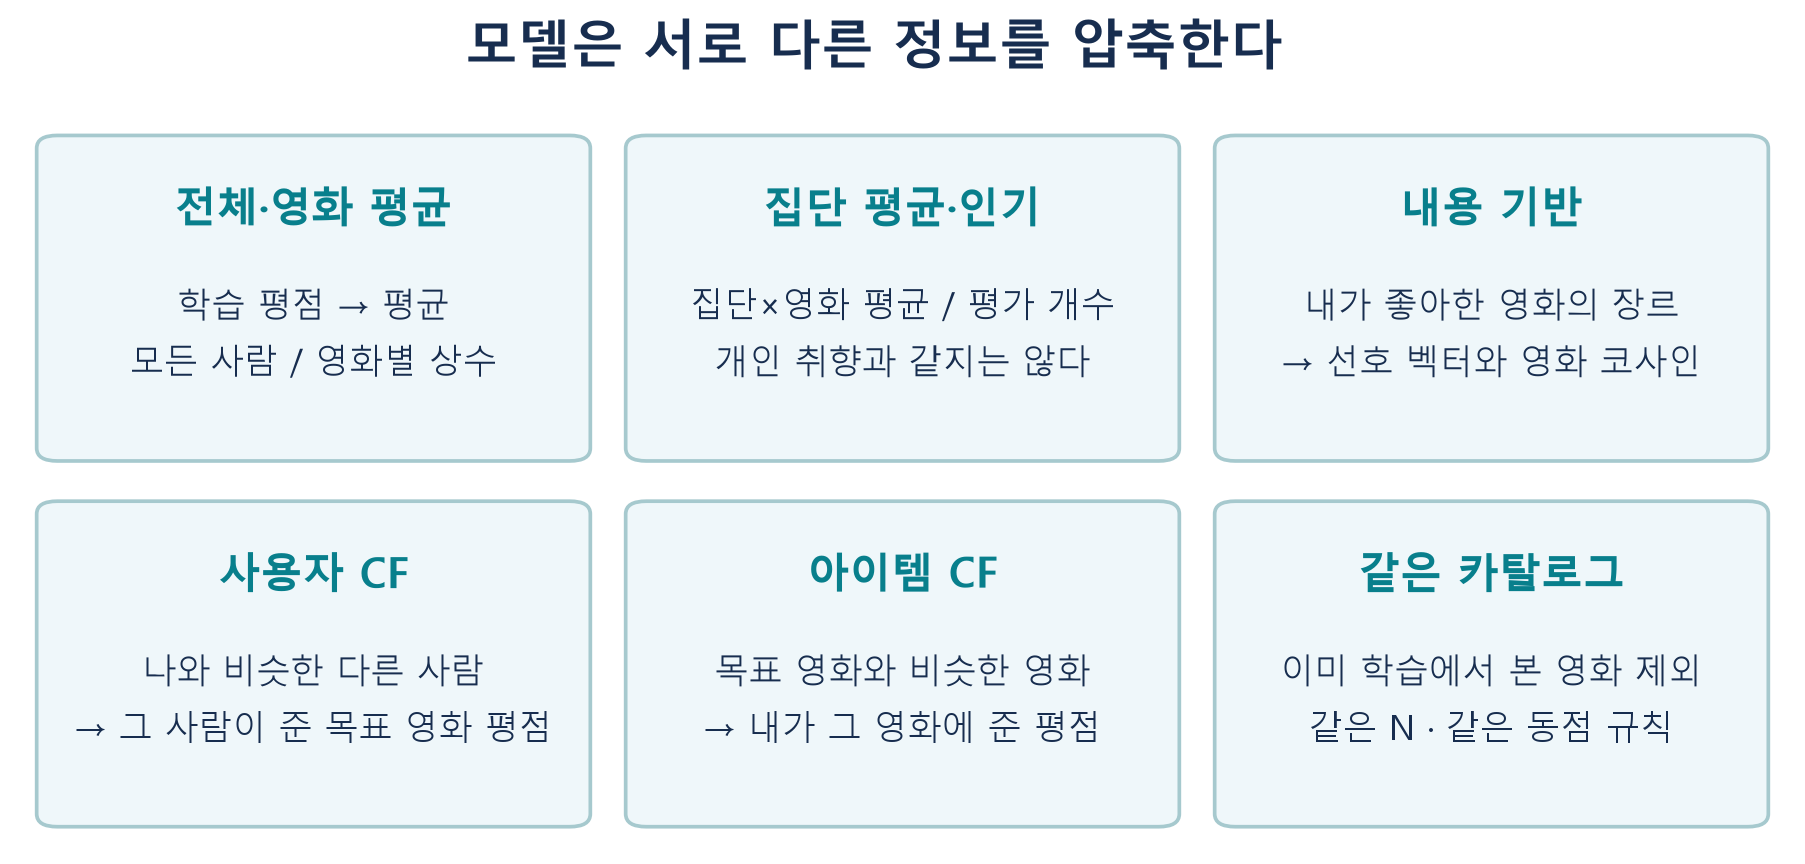


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/information-sources.png)


### A1 · 빈칸: 전체 평균과 영화 평균

목표: 평균을 계산할 때 미관측을 0으로 넣지 않습니다. `R[4]`는 D열입니다. 힌트: `mean()`은 NaN을 제외합니다. 자가 점검: 전체 평균의 분모는 관측 18개이며 25칸이 아닙니다.


In [ ]:
global_a1=None
movie_d_a1=None
explanation_a1=''
if global_a1 is not None: print(global_a1,movie_d_a1,explanation_a1)


## 2. 내용 벡터와 CF의 방향

단위 장르 벡터와 단위 선호 벡터의 내적은 코사인입니다. U1이 4점 이상을 준 A는 Action이고, D도 Action이므로 내용 점수는1입니다. 아이템 CF는 장르 대신 사용자들의 평점 패턴을 비교합니다.
평균 보정에서는 이웃의 평점에서 **그 이웃의 train 평균**을 뺀 뒤 대상 평균을 더합니다. 유사도를 Pearson으로 바꾸는 단계와 다릅니다.


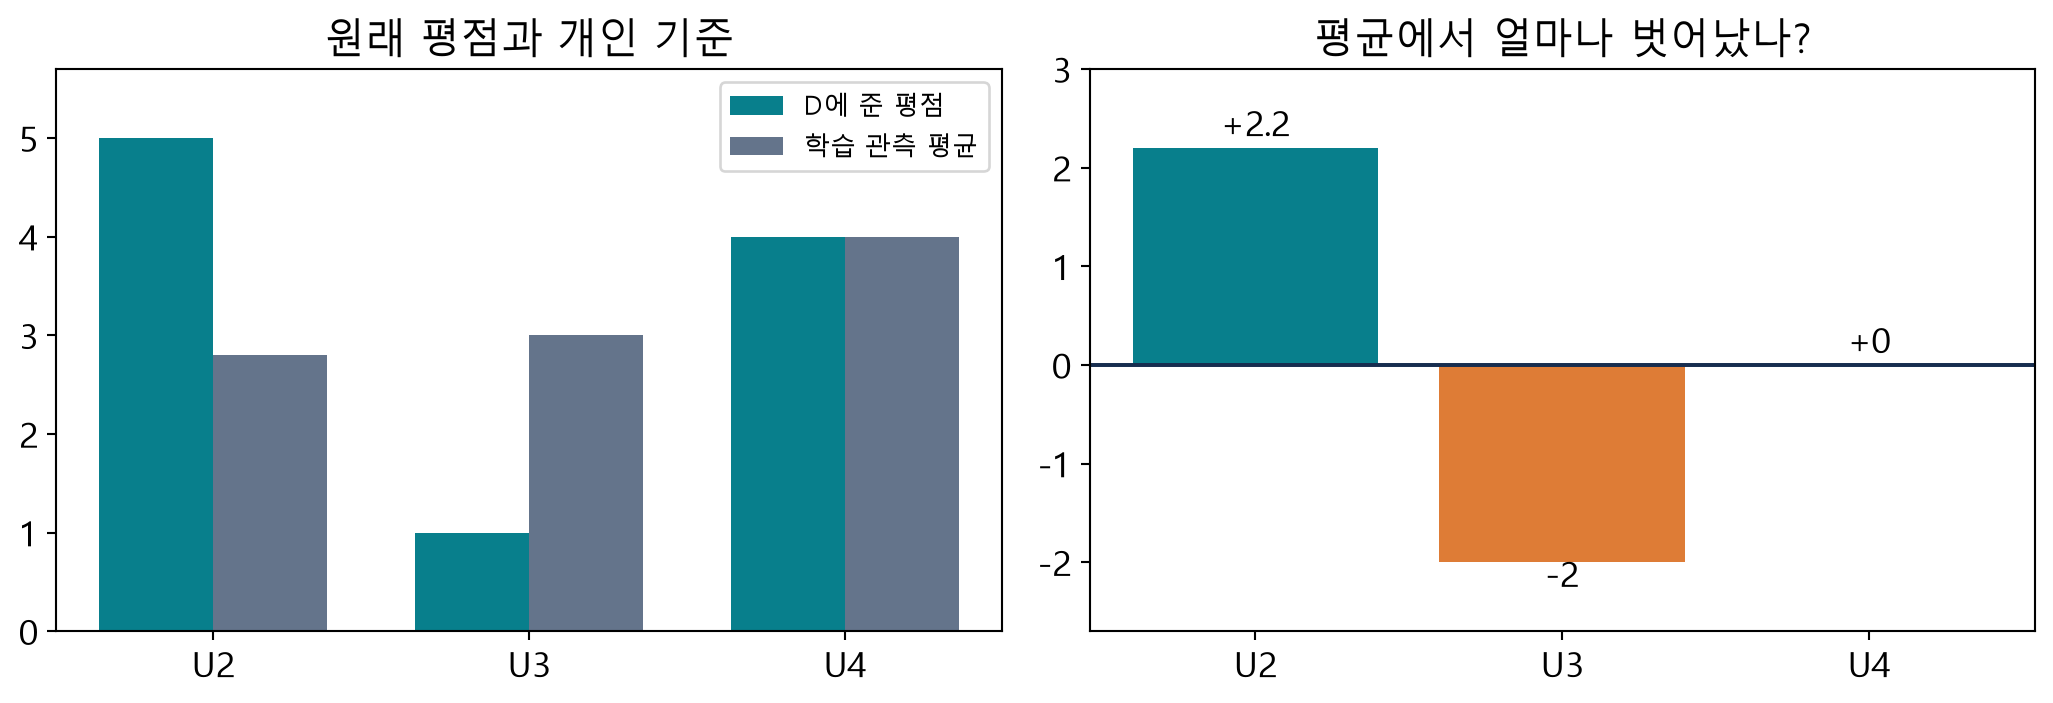


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/mean-centering.png)


In [ ]:
centered=EvidenceCF(k=2,min_common=3,centered=True).fit(toy.ratings)
evidence=centered.explain(1,4)
display(evidence)
manual=float(R.loc[1].mean()+evidence.contribution.sum())
prediction=float(centered.predict_details(pd.DataFrame({'user_id':[1],'movie_id':[4]})).prediction.iloc[0])
print('대상 평균 + 이웃 기여도 합:',manual,'구현 예측:',prediction)
print('Jaccard:',binary_jaccard({1,2},{2,3}))


### 짧은 텍스트로 TF–IDF 복습

아래 세 문장은 독자 예제입니다. `TfidfVectorizer.fit_transform`은 문장3개×학습된 단어 수의 희소행렬을 반환합니다. 기본 L2 정규화로 길이를 맞추며 `cosine_similarity`는 문장 간 방향의 유사도를 계산합니다. TF–IDF의 단어 특징과 이번 MovieLens의 장르 특징은 서로 다른 입력입니다.
[TfidfVectorizer 공식 API](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) · [cosine_similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
sentences=['space adventure hero','space hero mission','romantic comedy wedding']
vectorizer=TfidfVectorizer()
X_text=vectorizer.fit_transform(sentences)
display(pd.DataFrame(X_text.toarray(),columns=vectorizer.get_feature_names_out()).round(3))
display(pd.DataFrame(cosine_similarity(X_text)).round(3))


### A2 · 설명: 비슷함의 기준

목표: Pearson, 평균 보정, Jaccard를 구분합니다. Pearson으로 원평점을 집계하는 모델과 원평점 코사인으로 평균 편차를 집계하는 모델이 같은지 설명하세요. 힌트: 유사도를 만드는 단계와 평점을 집계하는 단계를 나눕니다. 자가 점검: 두 단계가 모두 답에 들어가야 합니다.


In [ ]:
answer_a2=''
print(answer_a2 if answer_a2 else '두 단계의 차이를 자신의 말로 기록하세요.')


## 3. 평점 오차를 표로 펼치기

부호가 다른 오차를 그냥 평균하면 상쇄됩니다. 절댓값과 제곱은 크기를 남깁니다. 아래 A와 B는 MAE가 같지만 RMSE가 다릅니다.


In [ ]:
actual=np.array([5.,4.,2.,1.])
pred_a=np.array([4.,3.,3.,2.]);pred_b=np.array([5.,4.,2.,5.])
error_a=actual-pred_a;error_b=actual-pred_b
display(pd.DataFrame({'actual':actual,'A':pred_a,'B':pred_b,'A_error':error_a,'B_error':error_b,
    'A_absolute':abs(error_a),'B_absolute':abs(error_b),'A_squared':error_a**2,'B_squared':error_b**2}))
for name,error in [('A',error_a),('B',error_b)]:
    print(name,'MAE',np.abs(error).mean(),'RMSE',np.sqrt(np.mean(error**2)))


$$\mathrm{MAE}=\frac1m\sum_{j=1}^m|y_j-\hat y_j|,\qquad \mathrm{RMSE}=\sqrt{\frac1m\sum_{j=1}^m(y_j-\hat y_j)^2}.$$


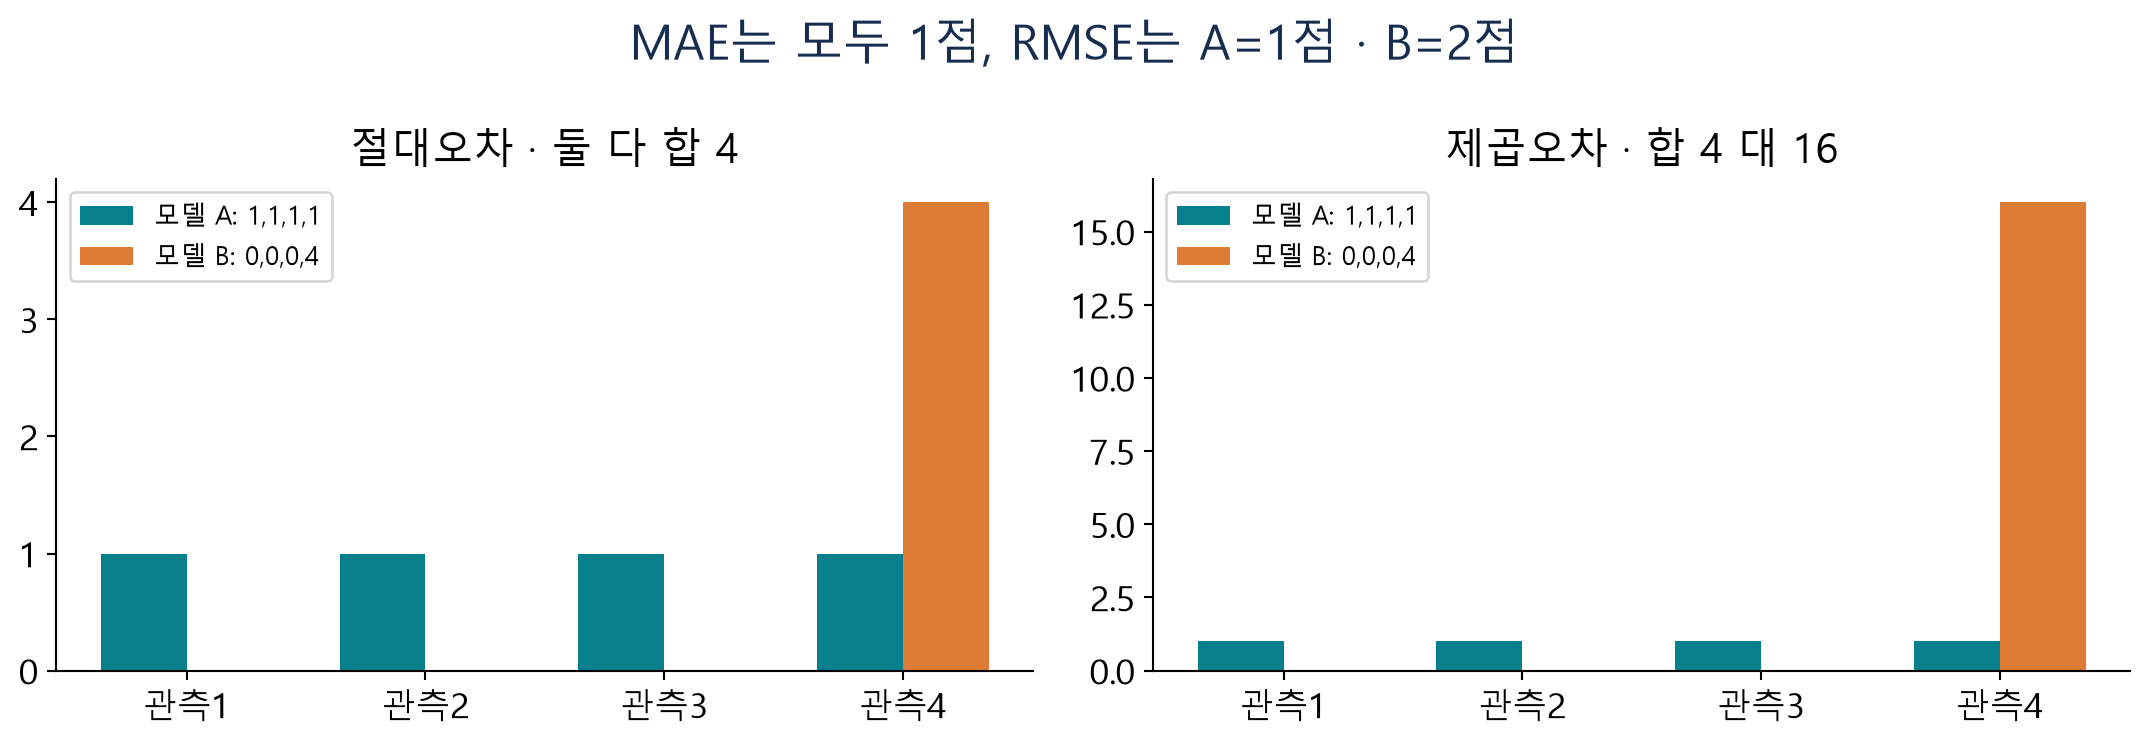


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/absolute-and-square.png)


### A3 · 빈칸: 새로운 오차 계산

실제 [5,2,4,1], 예측 [4,3,4,3]의 MAE와 RMSE를 계산하세요. 힌트: 제곱근은 제곱오차를 평균한 뒤 취합니다. 자가 점검: 두 지표는 유한하고 RMSE≥MAE입니다.


In [ ]:
actual_a3=np.array([5.,2.,4.,1.]);pred_a3=np.array([4.,3.,4.,3.])
mae_a3=None
rmse_a3=None
if mae_a3 is not None and rmse_a3 is not None:print(mae_a3,rmse_a3)


## 4. 적중 집합에서 위치별 기여로

관련 영화는 A,C,E입니다. `ranking_metrics(추천ID목록, 관련ID집합, k=N)`의 k는 이 함수에서 **목록 길이**입니다. CF 생성자의 이웃 수 k와 같은 이름이라도 역할이 다릅니다. 반환은 precision/recall/ndcg/hits의 사전입니다. 관련 집합이 비면 오류로 알려 줍니다.


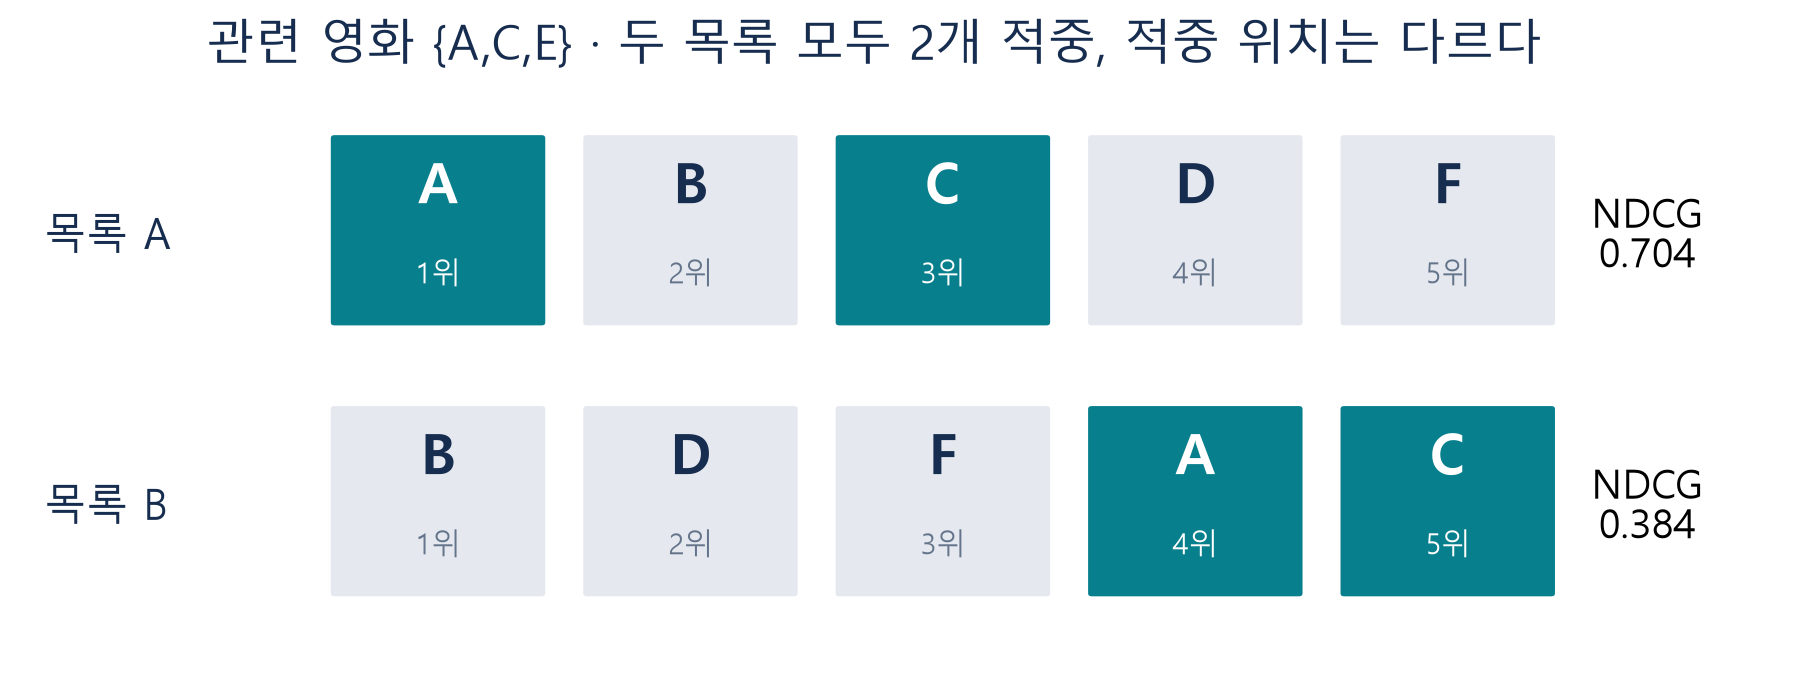


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05a-v2/course/notion/assets/w05a/ranking-cards.png)


$$P@N=\frac{|L_u^N\cap G_u|}{N},\quad R@N=\frac{|L_u^N\cap G_u|}{|G_u|},\quad NDCG@N=\frac{\sum_{j=1}^N rel_{u,j}/\log_2(j+1)}{IDCG@N}.$$


In [ ]:
relevant={1,3,5}
list_a=[1,2,3,4,6];list_b=[2,4,6,1,3]
rank_a=ranking_metrics(list_a,relevant,k=5)
rank_b=ranking_metrics(list_b,relevant,k=5)
display(pd.DataFrame([rank_a,rank_b],index=['A','B']))
discounts=1/np.log2(np.arange(2,7))
display(pd.DataFrame({'rank':range(1,6),'discount':discounts,
    'A_hit':[int(i in relevant) for i in list_a],
    'B_hit':[int(i in relevant) for i in list_b]}))


### A4 · 디버깅: 바뀐 분모

관련 영화8편 중 Top-10에서3편을 찾았습니다. 잘못 쓴 `precision=3/8, recall=3/10`을 고치세요. 코드 문자열을 수정한 뒤 직접 실행해도 됩니다. 자가 점검: 추천 자리 수는10, 관련 영화 수는8입니다.


In [ ]:
precision_a4=None
recall_a4=None
why_a4=''
if precision_a4 is not None:print(precision_a4,recall_a4,why_a4)


### A5 · 비교: 사용자 평균

U1은 관련1편 중1편, U2는 관련10편 중1편을 찾았습니다. macro Recall과 전체 적중/전체 관련 비율을 구하고 차이를 설명하세요. 힌트: 사용자 둘에 같은 가중치를 주는 것과 영화11편에 같은 가중치를 주는 것은 다릅니다.


In [ ]:
macro_a5=None
pooled_a5=None
reason_a5=''
if macro_a5 is not None:print(macro_a5,pooled_a5,reason_a5)


## 5. 웹 앱으로 순위와 지표를 연결하기

아래 callback은 문자열 목록 선택과 N을 받아 지표 표를 반환합니다. `ranking_metrics`의 구현을 복사하지 않고 공통 함수를 호출합니다. `Button.click`의 입력 순서가 함수의 인자 순서, 출력 순서가 반환 순서와 같아야 합니다. [Gradio Blocks 공식 문서](https://gradio.app/docs/gradio/blocks).


In [ ]:
def metric_callback(order,n):
    items=list_a if order=='앞쪽 적중' else list_b
    metrics=ranking_metrics(items,relevant,k=int(n))
    visible=items[:int(n)]
    summary=f'추천 {visible} / 관련 {sorted(relevant)} / N={int(n)}'
    return summary,pd.DataFrame([metrics])
with gr.Blocks(title='순위 지표 실험실') as metric_app:
    gr.Markdown('# 순위 지표 실험실\n적중 집합을 유지한 채 위치와 N을 바꾸세요.')
    order=gr.Dropdown(['앞쪽 적중','뒤쪽 적중'],value='앞쪽 적중',label='적중 위치')
    size=gr.Slider(1,5,value=5,step=1,label='추천 수 N')
    run=gr.Button('순위 지표 계산');summary=gr.Markdown();result=gr.Dataframe(interactive=False)
    run.click(metric_callback,[order,size],[summary,result])
display(metric_callback('앞쪽 적중',5)[1])


### A6 · 앱 연결: 출력 두 개 맞추기

아래 연습 앱의 버튼에 `metric_callback`을 연결하세요. 입력은 순위 선택과 N, 출력은 요약과 표입니다. 힌트: `button.click(함수, inputs=[...], outputs=[...])`. 자가 점검: 함수의 반환값2개와 출력 컴포넌트2개가 같은 순서여야 합니다. 위 완성 앱과는 독립된 연습입니다.


In [ ]:
with gr.Blocks() as exercise_app_a:
    order_a6=gr.Dropdown(['앞쪽 적중','뒤쪽 적중'],value='앞쪽 적중')
    n_a6=gr.Slider(1,5,value=5,step=1)
    button_a6=gr.Button('내 계산')
    summary_a6=gr.Markdown();table_a6=gr.Dataframe(interactive=False)
    # 여기에 버튼 이벤트를 연결하세요.


In [ ]:
assert np.isclose(manual,prediction) and np.isclose(prediction,3.565507,atol=1e-6)
assert np.isclose(np.abs(error_a).mean(),1) and np.isclose(np.sqrt(np.mean(error_b**2)),2)
assert rank_a['precision']==rank_b['precision']==.4 and rank_a['ndcg']>rank_b['ndcg']
assert len(small_outputs)==12 and X_text.shape[0]==3
assert metric_callback('앞쪽 적중',5)[1].shape==(1,4)
assert isinstance(metric_app,gr.Blocks)
print('W05A_A_RUNTIME_PASS: 모델·수계산·순위지표·앱 callback 검증')


웹 앱을 실행한 뒤 같은 N에서 적중 위치만 바꾸고, 다음에는 같은 목록에서 N만 바꿉니다. 공유 주소는 런타임 종료 시 만료됩니다. 로컬 자동 검증은 서버 대신 callback과 이벤트를 검사하며 실제 웹 화면 검사는 별도로 수행합니다.


In [ ]:
if IN_COLAB:
    metric_app.launch(share=True,debug=False)
else:
    print('로컬 화면 실행: metric_app.launch()')


## 점검 퀴즈

1. 미관측을 0점으로 채운 평균이 잘못되는 이유는 무엇인가?
2. 내용 기반과 아이템 CF의 입력 정보는 어떻게 다른가?
3. 같은 MAE에서 RMSE가 달라지는 이유는 무엇인가?
4. Precision과 Recall의 분모는 각각 무엇인가?
5. 같은 적중 수에서 NDCG가 달라지는 이유는 무엇인가?

## 핵심 정리와 다음 실습

정보의 출처, 점수 단위, 평가 질문을 구분했습니다. 이제 실습 B에서 같은 데이터 분할과 후보로 모델을 비교하고 설정을 바꿉니다.
주교재1–3장, [Stanford IR 평가](https://nlp.stanford.edu/IR-book/html/htmledition/evaluation-of-ranked-retrieval-results-1.html), [MovieLens](https://grouplens.org/datasets/movielens/100k/). 합성 예제와 화면은 독립 제작입니다.
